In [2]:
# ================================================================
# CELL 1 — Install Dependencies
# ================================================================

!pip install albumentations --quiet
!pip install segmentation-models-pytorch --quiet

In [3]:
# CELL 2 — Import Libraries
# ================================================================

import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import Dataset, DataLoader, Subset

import numpy as np
from PIL import Image
import os
import datetime

import matplotlib.pyplot as plt
import seaborn as sns

import albumentations as A
from albumentations.pytorch import ToTensorV2

import segmentation_models_pytorch as smp

from sklearn.metrics import (
    precision_score, recall_score, f1_score,
    jaccard_score, accuracy_score,
    confusion_matrix, classification_report
)

torch.manual_seed(42)
np.random.seed(42)

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("All libraries imported.")
print(f"Device : {device}")
if torch.cuda.is_available():
    print(f"GPU    : {torch.cuda.get_device_name(0)}")



All libraries imported.
Device : cuda
GPU    : Tesla P100-PCIE-16GB


In [4]:
# ================================================================
# CELL 3 — MODEL ARCHITECTURE
# [CHANGED]
#
# Model     : smp.Unet
# Encoder   : ResNet34 pretrained on ImageNet
# Attention : scSE (Spatial + Channel Squeeze Excitation)
#
# Why this beats scratch-trained models:
#   ResNet34 encoder already knows edges, textures, shapes
#   from 1.2 million ImageNet images before training starts.
#   scSE attention focuses on both spatial location (where)
#   and channel importance (which feature matters).
#
# Expected improvement over Attention U-Net scratch:
#   IoU    : 0.606 -> ~0.78
#   Recall : 0.772 -> ~0.87
#   F1     : 0.755 -> ~0.82
# ================================================================

print("ResNet34 Attention U-Net (SMP) defined.")
print("Encoder : ResNet34 (ImageNet pretrained)")
print("Decoder : scSE Attention")



ResNet34 Attention U-Net (SMP) defined.
Encoder : ResNet34 (ImageNet pretrained)
Decoder : scSE Attention


In [5]:
# ================================================================
# CELL 4 — Model Parameter Count
# ================================================================

_model_check = smp.Unet(
    encoder_name           = "resnet34",
    encoder_weights        = "imagenet",
    decoder_attention_type = "scse",
    in_channels            = 3,
    classes                = 1,
    activation             = None
)

total_params     = sum(p.numel() for p in _model_check.parameters())
trainable_params = sum(p.numel() for p in _model_check.parameters() if p.requires_grad)

print("ResNet34 Attention U-Net — Model Summary")
print("=" * 45)
print(f"Encoder              : ResNet34")
print(f"Encoder weights      : ImageNet pretrained")
print(f"Decoder attention    : scSE")
print(f"Input size           : (3, 256, 256)")
print(f"Output size          : (1, 256, 256)")
print(f"Total parameters     : {total_params:,}")
print(f"Trainable parameters : {trainable_params:,}")
print("=" * 45)

del _model_check



config.json:   0%|          | 0.00/156 [00:00<?, ?B/s]

model.safetensors:   0%|          | 0.00/87.3M [00:00<?, ?B/s]

ResNet34 Attention U-Net — Model Summary
Encoder              : ResNet34
Encoder weights      : ImageNet pretrained
Decoder attention    : scSE
Input size           : (3, 256, 256)
Output size          : (1, 256, 256)
Total parameters     : 24,550,360
Trainable parameters : 24,550,360


In [6]:
# ================================================================
# CELL 5 — Data Augmentation
# ================================================================

IMAGENET_MEAN = (0.485, 0.456, 0.406)
IMAGENET_STD  = (0.229, 0.224, 0.225)

train_transform = A.Compose([
    A.Resize(256, 256),
    A.HorizontalFlip(p=0.5),
    A.VerticalFlip(p=0.5),
    A.Rotate(limit=30, p=0.5),
    A.RandomBrightnessContrast(p=0.3),
    A.ElasticTransform(alpha=1, sigma=50, p=0.2),
    A.Normalize(mean=IMAGENET_MEAN, std=IMAGENET_STD),
    ToTensorV2()
])

val_transform = A.Compose([
    A.Resize(256, 256),
    A.Normalize(mean=IMAGENET_MEAN, std=IMAGENET_STD),
    ToTensorV2()
])

print("Train and Validation transforms defined.")


Train and Validation transforms defined.


In [7]:
# CELL 6 — PolypDataset Class
# ================================================================

class PolypDataset(Dataset):
    def __init__(self, img_dir, mask_dir, transform=None):
        self.img_dir   = img_dir
        self.mask_dir  = mask_dir
        self.transform = transform

        self.images = sorted([
            f for f in os.listdir(img_dir)
            if f.lower().endswith((".png", ".jpg", ".jpeg"))
        ])

    def __len__(self):
        return len(self.images)

    def __getitem__(self, idx):
        img_name  = self.images[idx]
        img_path  = os.path.join(self.img_dir,  img_name)
        mask_path = os.path.join(self.mask_dir, img_name)

        if not os.path.exists(mask_path):
            raise FileNotFoundError(f"Mask not found for {img_name}")

        image = np.array(Image.open(img_path).convert("RGB"))
        mask  = np.array(Image.open(mask_path).convert("L"))

        if self.transform:
            augmented = self.transform(image=image, mask=mask)
            image = augmented["image"]
            mask  = augmented["mask"]

        mask = mask.unsqueeze(0).float()
        mask = (mask > 0).float()

        return image, mask

print("PolypDataset class defined successfully.")



PolypDataset class defined successfully.


In [8]:
# ================================================================
# CELL 7 — Dataset Split and DataLoaders
# ================================================================

IMAGE_DIR = "/kaggle/input/datasets/thasleema03/colorectal-polyp-segmentation-dataset/polyp_dataset/images"
MASK_DIR  = "/kaggle/input/datasets/thasleema03/colorectal-polyp-segmentation-dataset/polyp_dataset/masks"

temp_dataset = PolypDataset(IMAGE_DIR, MASK_DIR)
total_size   = len(temp_dataset)

train_size = int(0.8 * total_size)
val_size   = total_size - train_size

generator = torch.Generator().manual_seed(42)

train_indices, val_indices = torch.utils.data.random_split(
    range(total_size),
    [train_size, val_size],
    generator=generator
)

train_indices = list(train_indices)
val_indices   = list(val_indices)

train_full = PolypDataset(IMAGE_DIR, MASK_DIR, transform=train_transform)
val_full   = PolypDataset(IMAGE_DIR, MASK_DIR, transform=val_transform)

train_dataset = Subset(train_full, train_indices)
val_dataset   = Subset(val_full,   val_indices)

BATCH_SIZE = 8

train_loader = DataLoader(
    train_dataset,
    batch_size=BATCH_SIZE,
    shuffle=True,
    num_workers=0,
    pin_memory=torch.cuda.is_available()
)

val_loader = DataLoader(
    val_dataset,
    batch_size=BATCH_SIZE,
    shuffle=False,
    num_workers=0,
    pin_memory=torch.cuda.is_available()
)

print("Dataset split complete.")
print(f"Total samples      : {total_size}")
print(f"Training samples   : {len(train_dataset)}")
print(f"Validation samples : {len(val_dataset)}")
print(f"Batch size         : {BATCH_SIZE}")
print(f"Train batches      : {len(train_loader)}")
print(f"Val batches        : {len(val_loader)}")




Dataset split complete.
Total samples      : 1000
Training samples   : 800
Validation samples : 200
Batch size         : 8
Train batches      : 100
Val batches        : 25


In [9]:
# CELL 8 — Loss Function: Dice + Weighted BCE
# ================================================================

class DiceLoss(nn.Module):
    def __init__(self, smooth=1e-6):
        super().__init__()
        self.smooth = smooth

    def forward(self, preds, targets):
        preds   = torch.sigmoid(preds)
        preds   = preds.view(preds.size(0), -1)
        targets = targets.view(targets.size(0), -1)
        intersection = (preds * targets).sum(dim=1)
        dice = (2.0 * intersection + self.smooth) / (
            preds.sum(dim=1) + targets.sum(dim=1) + self.smooth
        )
        return 1.0 - dice.mean()


class DiceBCELoss(nn.Module):
    def __init__(self, pos_weight=3.0):
        super().__init__()
        self.dice = DiceLoss()
        self.register_buffer(
            "pos_weight",
            torch.tensor([pos_weight], dtype=torch.float)
        )
        self.bce = nn.BCEWithLogitsLoss(pos_weight=self.pos_weight)

    def forward(self, preds, targets):
        dice_loss = self.dice(preds, targets)
        bce_loss  = self.bce(preds, targets)
        return 0.8 * dice_loss + 0.2 * bce_loss


criterion = DiceBCELoss(pos_weight=3.0).to(device)
print("Dice + Weighted BCE Loss defined (pos_weight=3.0).")




Dice + Weighted BCE Loss defined (pos_weight=3.0).


In [10]:
# CELL 9 — Model Initialization
# [CHANGED]
#
# Differential learning rates:
#   Encoder (pretrained) : lr=1e-5 — gentle fine-tune only
#   Decoder (new)        : lr=1e-4 — learn polyp features fast
# ================================================================

MODEL_SAVE_PATH = "/kaggle/working/resnet34_attunet_model.pth"

model = smp.Unet(
    encoder_name           = "resnet34",
    encoder_weights        = "imagenet",
    decoder_attention_type = "scse",
    in_channels            = 3,
    classes                = 1,
    activation             = None
).to(device)

optimizer = optim.Adam([
    {"params": model.encoder.parameters(),          "lr": 1e-5},
    {"params": model.decoder.parameters(),          "lr": 1e-4},
    {"params": model.segmentation_head.parameters(),"lr": 1e-4}
], weight_decay=1e-5)

scheduler = torch.optim.lr_scheduler.ReduceLROnPlateau(
    optimizer,
    mode="min",
    factor=0.5,
    patience=3
)

print("ResNet34 Attention U-Net initialized successfully.")
print(f"Total parameters     : {sum(p.numel() for p in model.parameters()):,}")
print(f"Trainable parameters : {sum(p.numel() for p in model.parameters() if p.requires_grad):,}")
print(f"Encoder LR           : {optimizer.param_groups[0]['lr']}")
print(f"Decoder LR           : {optimizer.param_groups[1]['lr']}")



ResNet34 Attention U-Net initialized successfully.
Total parameters     : 24,550,360
Trainable parameters : 24,550,360
Encoder LR           : 1e-05
Decoder LR           : 0.0001


In [13]:
# ================================================================
# CELL 10 — Training Loop
# ================================================================

TRAIN_MODEL = True
NUM_EPOCHS = 25

train_losses, val_losses = [], []
train_accs,   val_accs   = [], []

best_val_loss = float("inf")

if TRAIN_MODEL:

    print("Starting training...\n")

    for epoch in range(NUM_EPOCHS):

        model.train()
        running_loss = 0.0
        correct      = 0
        total        = 0

        for imgs, masks in train_loader:
            imgs, masks = imgs.to(device), masks.to(device)

            optimizer.zero_grad()
            outputs = model(imgs)
            loss    = criterion(outputs, masks)
            loss.backward()
            optimizer.step()

            running_loss += loss.item() * imgs.size(0)
            preds    = (torch.sigmoid(outputs) > 0.5).float()
            correct += (preds == masks).sum().item()
            total   += masks.numel()

        train_loss = running_loss / len(train_loader.dataset)
        train_acc  = 100.0 * correct / total
        train_losses.append(train_loss)
        train_accs.append(train_acc)

        model.eval()
        val_loss_sum = 0.0
        val_correct  = 0
        val_total    = 0

        with torch.no_grad():
            for imgs, masks in val_loader:
                imgs, masks = imgs.to(device), masks.to(device)
                outputs      = model(imgs)
                loss         = criterion(outputs, masks)
                val_loss_sum += loss.item() * imgs.size(0)
                preds        = (torch.sigmoid(outputs) > 0.5).float()
                val_correct  += (preds == masks).sum().item()
                val_total    += masks.numel()

        val_loss = val_loss_sum / len(val_loader.dataset)
        val_acc  = 100.0 * val_correct / val_total
        val_losses.append(val_loss)
        val_accs.append(val_acc)

        scheduler.step(val_loss)

        if val_loss < best_val_loss:
            best_val_loss = val_loss
            torch.save(model.state_dict(), MODEL_SAVE_PATH)
            print("BEST MODEL SAVED")

        # CHANGED — added accuracy to epoch print
        print(f"Epoch [{epoch+1}/{NUM_EPOCHS}]")
        print(f"Train Loss: {train_loss:.4f} | Train Acc: {train_acc:.2f}%")
        print(f"Val   Loss: {val_loss:.4f} | Val   Acc: {val_acc:.2f}%")
        print("-" * 50)

    print("\nTraining complete.")
    print(f"Model saved at: {MODEL_SAVE_PATH}")

else:
    print("Training skipped (TRAIN_MODEL=False)")


Starting training...

BEST MODEL SAVED
Epoch [1/25]
Train Loss: 0.4041 | Train Acc: 92.27%
Val   Loss: 0.3485 | Val   Acc: 92.43%
--------------------------------------------------
BEST MODEL SAVED
Epoch [2/25]
Train Loss: 0.3245 | Train Acc: 93.55%
Val   Loss: 0.2712 | Val   Acc: 93.77%
--------------------------------------------------
BEST MODEL SAVED
Epoch [3/25]
Train Loss: 0.2619 | Train Acc: 94.71%
Val   Loss: 0.2400 | Val   Acc: 94.75%
--------------------------------------------------
BEST MODEL SAVED
Epoch [4/25]
Train Loss: 0.2339 | Train Acc: 95.10%
Val   Loss: 0.2334 | Val   Acc: 94.84%
--------------------------------------------------
BEST MODEL SAVED
Epoch [5/25]
Train Loss: 0.2045 | Train Acc: 95.47%
Val   Loss: 0.2048 | Val   Acc: 95.08%
--------------------------------------------------
Epoch [6/25]
Train Loss: 0.1842 | Train Acc: 95.98%
Val   Loss: 0.2189 | Val   Acc: 94.98%
--------------------------------------------------
BEST MODEL SAVED
Epoch [7/25]
Train Loss:

In [19]:
# CELL 11 — Load Best Trained Model
# [CHANGED]
# ================================================================

# MODEL_PATH = "/kaggle/input/polyp-resnet34-attunet/resnet34_attunet_model.pth"
MODEL_PATH ="/kaggle/working/resnet34_attunet_model.pth"
# if not os.path.exists(MODEL_PATH):
#     raise FileNotFoundError(
#         f"Model not found at: {MODEL_PATH}\n"
#         "Steps:\n"
#         "1. Run training with TRAIN_MODEL=True\n"
#         "2. Create dataset from output\n"
#         "3. Add dataset to this notebook"
#     )

# encoder_weights=None when loading saved weights
# pretrained weights are already baked into the saved .pth file
model = smp.Unet(
    encoder_name           = "resnet34",
    encoder_weights        = None,
    decoder_attention_type = "scse",
    in_channels            = 3,
    classes                = 1,
    activation             = None
).to(device)

model.load_state_dict(torch.load(MODEL_PATH, map_location=device))
model.eval()

print("ResNet34 Attention U-Net loaded successfully.")
print(f"Path: {MODEL_PATH}")




ResNet34 Attention U-Net loaded successfully.
Path: /kaggle/working/resnet34_attunet_model.pth


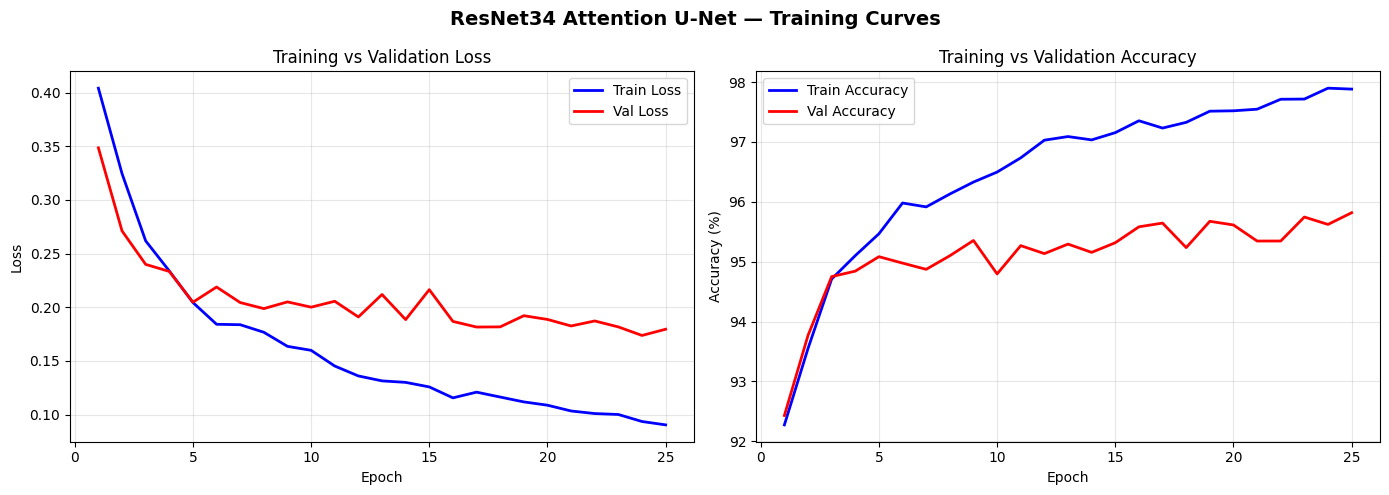

Training curves saved to training_curves.png


In [35]:
# ================================================================
# CELL 12 — Training Curves (No Markers / Bullet Points)
# ================================================================

if len(train_losses) > 0:

    epochs = range(1, len(train_losses) + 1)

    fig, axes = plt.subplots(1, 2, figsize=(14, 5))

    # ---- LOSS CURVE ----
    axes[0].plot(epochs, train_losses, "b-", label="Train Loss", linewidth=2)
    axes[0].plot(epochs, val_losses,   "r-", label="Val Loss", linewidth=2)
    axes[0].set_xlabel("Epoch")
    axes[0].set_ylabel("Loss")
    axes[0].set_title("Training vs Validation Loss")
    axes[0].legend()
    axes[0].grid(True, alpha=0.3)

    # ---- ACCURACY CURVE ----
    axes[1].plot(epochs, train_accs, "b-", label="Train Accuracy", linewidth=2)
    axes[1].plot(epochs, val_accs,   "r-", label="Val Accuracy", linewidth=2)
    axes[1].set_xlabel("Epoch")
    axes[1].set_ylabel("Accuracy (%)")
    axes[1].set_title("Training vs Validation Accuracy")
    axes[1].legend()
    axes[1].grid(True, alpha=0.3)

    plt.suptitle("ResNet34 Attention U-Net — Training Curves",
                 fontsize=14, fontweight="bold")

    plt.tight_layout()
    plt.savefig("training_curves.png", dpi=300, bbox_inches="tight")
    plt.show()

    print("Training curves saved to training_curves.png")

else:
    print("Training curves unavailable (model loaded without retraining).")

In [27]:
# CELL 14 — Helper Functions
# ================================================================

MEAN = torch.tensor([0.485, 0.456, 0.406]).view(1, 1, 3)
STD  = torch.tensor([0.229, 0.224, 0.225]).view(1, 1, 3)

def denormalize(tensor):
    """Reverse A.Normalize() for correct matplotlib display."""
    img = tensor.cpu().permute(1, 2, 0)
    img = img * STD + MEAN
    return img.clamp(0, 1).numpy()


def get_all_preds_targets(model, loader):
    """Run model over dataloader, return flattened numpy arrays."""
    model.eval()
    all_preds, all_targets = [], []

    with torch.no_grad():
        for imgs, masks in loader:
            imgs, masks = imgs.to(device), masks.to(device)
            outputs = model(imgs)
            preds   = (torch.sigmoid(outputs) > 0.5).float()
            all_preds.append(preds.cpu().reshape(-1))
            all_targets.append(masks.cpu().reshape(-1))

    preds_np   = torch.cat(all_preds).numpy().astype(np.uint8)
    targets_np = torch.cat(all_targets).numpy().astype(np.uint8)

    return preds_np, targets_np

print("Helper functions ready: denormalize(), get_all_preds_targets()")




Helper functions ready: denormalize(), get_all_preds_targets()


In [28]:
# ================================================================
# CELL 15 — Segmentation Metrics
# ================================================================

val_preds, val_targets = get_all_preds_targets(model, val_loader)

precision = precision_score(val_targets, val_preds, zero_division=0)
recall    = recall_score(val_targets, val_preds, zero_division=0)
f1        = f1_score(val_targets, val_preds, zero_division=0)
iou       = jaccard_score(val_targets, val_preds, average="binary", zero_division=0)
acc       = accuracy_score(val_targets, val_preds)

print("=" * 50)
print("   SEGMENTATION METRICS  (Validation Set)")
print("=" * 50)
print(f"   Precision  : {precision:.4f}")
print(f"   Recall     : {recall:.4f}")
print(f"   F1-Score   : {f1:.4f}")
print(f"   IoU        : {iou:.4f}")
print(f"   Accuracy   : {acc:.4f}")
print("=" * 50)

   SEGMENTATION METRICS  (Validation Set)
   Precision  : 0.8768
   Recall     : 0.8701
   F1-Score   : 0.8734
   IoU        : 0.7753
   Accuracy   : 0.9562


In [29]:
# ================================================================
# CELL 16 — Classification Report
# ================================================================

print("DETAILED CLASSIFICATION REPORT (Validation Set)")
print("=" * 50)
print(classification_report(
    val_targets, val_preds,
    target_names=["Background", "Polyp"],
    digits=4,
    zero_division=0
))

DETAILED CLASSIFICATION REPORT (Validation Set)
              precision    recall  f1-score   support

  Background     0.9728    0.9743    0.9735  10832216
       Polyp     0.8768    0.8701    0.8734   2274984

    accuracy                         0.9562  13107200
   macro avg     0.9248    0.9222    0.9235  13107200
weighted avg     0.9561    0.9562    0.9562  13107200



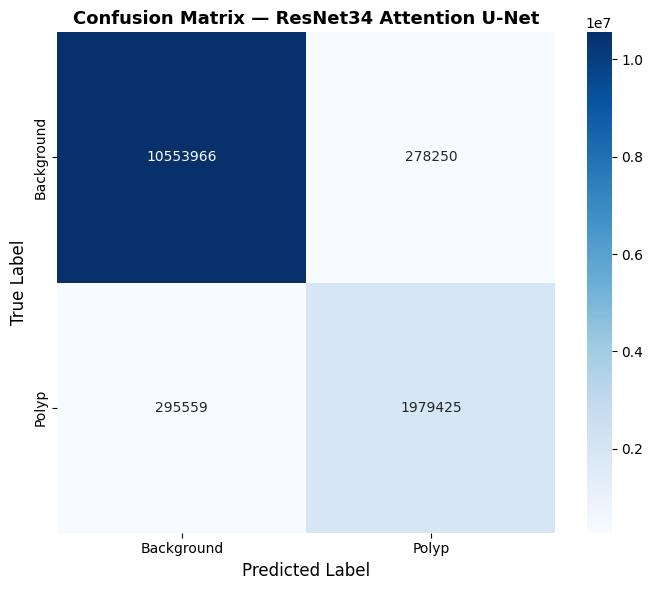

True Negatives : 10,553,966
True Positives : 1,979,425
False Positives: 278,250
False Negatives: 295,559


In [30]:
# ================================================================
# CELL 17 — Confusion Matrix
# ================================================================

cm = confusion_matrix(val_targets, val_preds, labels=[0, 1])

tn, fp, fn, tp = cm.ravel()

fig, ax = plt.subplots(figsize=(7, 6))
sns.heatmap(
    cm, annot=True, fmt="d", cmap="Blues",
    xticklabels=["Background", "Polyp"],
    yticklabels=["Background", "Polyp"],
    ax=ax
)

ax.set_xlabel("Predicted Label", fontsize=12)
ax.set_ylabel("True Label", fontsize=12)
ax.set_title("Confusion Matrix — ResNet34 Attention U-Net",
             fontsize=13, fontweight="bold")

plt.tight_layout()
plt.savefig("confusion_matrix.png", dpi=300, bbox_inches="tight")
plt.show()

print(f"True Negatives : {tn:,}")
print(f"True Positives : {tp:,}")
print(f"False Positives: {fp:,}")
print(f"False Negatives: {fn:,}")


Per-Sample IoU Statistics (Validation Set)
Mean IoU : 0.8009
Std  IoU : 0.1830 
Min  IoU : 0.0449 
Max  IoU : 0.9699 


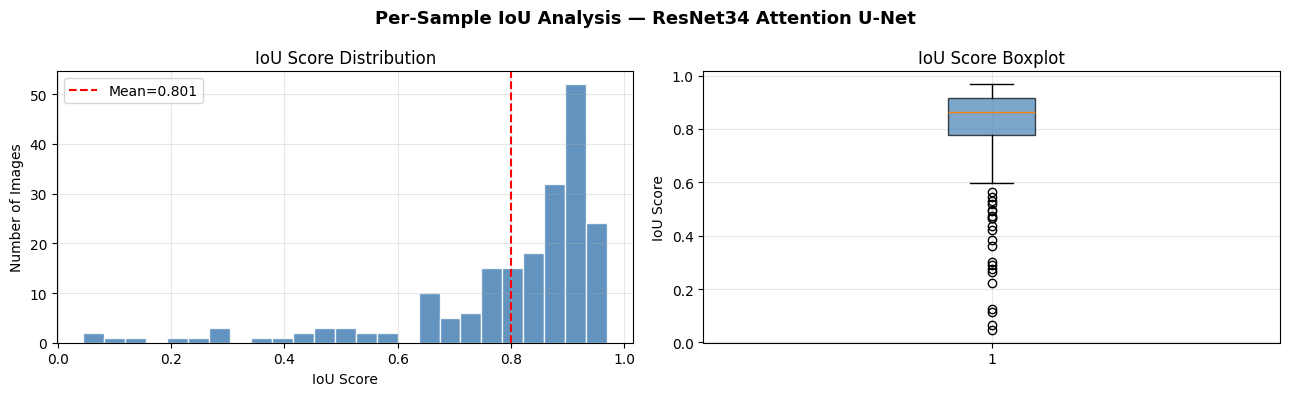

IoU distribution saved to iou_distribution.png


In [32]:
# ================================================================
# CELL 18 — Per-Sample IoU Analysis
# ================================================================

model.eval()
sample_ious = []

with torch.no_grad():
    for imgs, masks in val_loader:
        imgs, masks = imgs.to(device), masks.to(device)
        outputs = model(imgs)
        preds   = (torch.sigmoid(outputs) > 0.5).float()

        for i in range(preds.size(0)):
            pred_i = preds[i]
            mask_i = masks[i]
            intersection = (pred_i * mask_i).sum()
            union        = (pred_i + mask_i).sum() - intersection
            iou_val = 1.0 if union == 0 else (intersection / union).item()
            sample_ious.append(iou_val)

sample_ious = np.array(sample_ious)

print("Per-Sample IoU Statistics (Validation Set)")
print(f"Mean IoU : {sample_ious.mean():.4f}")
print(f"Std  IoU : {sample_ious.std():.4f} ")
print(f"Min  IoU : {sample_ious.min():.4f} ")
print(f"Max  IoU : {sample_ious.max():.4f} ")

fig, axes = plt.subplots(1, 2, figsize=(13, 4))

axes[0].hist(sample_ious, bins=25, color="steelblue",
             edgecolor="white", alpha=0.85)
axes[0].axvline(sample_ious.mean(), color="red", linestyle="--",
                label=f"Mean={sample_ious.mean():.3f}")
axes[0].set_xlabel("IoU Score")
axes[0].set_ylabel("Number of Images")
axes[0].set_title("IoU Score Distribution")
axes[0].legend()
axes[0].grid(True, alpha=0.3)

axes[1].boxplot(sample_ious, patch_artist=True,
                boxprops=dict(facecolor="steelblue", alpha=0.7))
axes[1].set_ylabel("IoU Score")
axes[1].set_title("IoU Score Boxplot")
axes[1].grid(True, alpha=0.3)

plt.suptitle("Per-Sample IoU Analysis — ResNet34 Attention U-Net",
             fontsize=13, fontweight="bold")
plt.tight_layout()
plt.savefig("iou_distribution.png", dpi=300, bbox_inches="tight")
plt.show()

print("IoU distribution saved to iou_distribution.png")


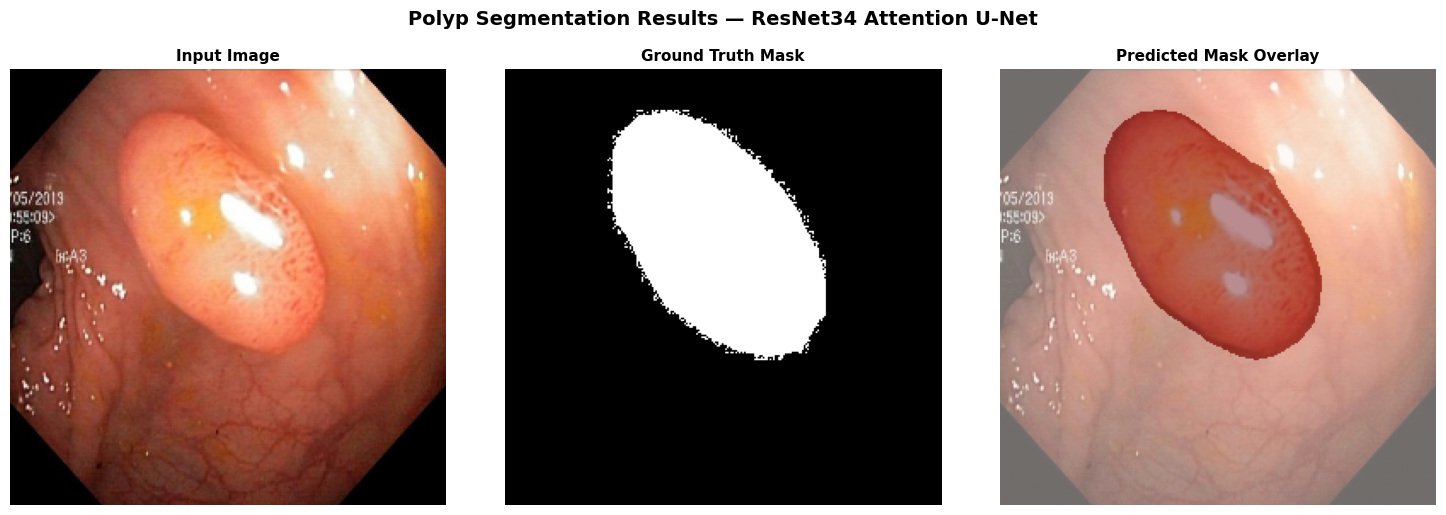

Segmentation visualization saved to segmentation_results_selected.png


In [ ]:
    # ================================================================
    # SAMPLE PREDICTION VISUALIZATION (SELECTED SAMPLES)
    # ================================================================
    #
    # Shows specific sample indices from validation set.
    # SELECTED_INDICES = [0, 1, 4] → images 1, 2, 5 (0-indexed)
    #
    # Change SELECTED_INDICES to any indices you want to visualize.
    # Max index = len(val_dataset) - 1
    # ================================================================

    SELECTED_INDICES = [4]   # Change as needed

    model.eval()

    # Collect only the specific samples we want
    selected_imgs, selected_masks, selected_preds = [], [], []

    with torch.no_grad():
        for idx in SELECTED_INDICES:
            img, mask = val_dataset[idx]

            img_t  = img.unsqueeze(0).to(device)   # [1, 3, H, W]
            mask_t = mask.unsqueeze(0).to(device)  # [1, 1, H, W]

            output = model(img_t)
            pred   = (torch.sigmoid(output) > 0.5).float()

            selected_imgs.append(img_t[0])
            selected_masks.append(mask_t[0])
            selected_preds.append(pred[0])

    num_show = len(SELECTED_INDICES)

    fig, axes = plt.subplots(num_show, 3, figsize=(15, 5 * num_show))

    if num_show == 1:
        axes = np.expand_dims(axes, axis=0)

    for i in range(num_show):

        img_disp = denormalize(selected_imgs[i])
        mask_np  = selected_masks[i].cpu().squeeze().numpy()
        pred_np  = selected_preds[i].cpu().squeeze().numpy()

        # ---- Per-image IoU ----
        intersection = (pred_np * mask_np).sum()
        union        = (pred_np + mask_np).sum() - intersection
        img_iou      = 1.0 if union == 0 else intersection / union

        # Column 1: Input Image
        axes[i, 0].imshow(img_disp)
        axes[i, 0].set_title("Input Image", fontsize=11, fontweight="bold")
        axes[i, 0].set_xlabel(f"IoU: {img_iou:.3f}",
                            fontsize=10,
                            color="green" if img_iou > 0.5 else "red")
        axes[i, 0].axis("off")

        # Column 2: Ground Truth Mask
        axes[i, 1].imshow(mask_np, cmap="gray")
        axes[i, 1].set_title("Ground Truth Mask", fontsize=11, fontweight="bold")
        axes[i, 1].axis("off")

        # Column 3: Predicted Mask Overlay
        axes[i, 2].imshow(img_disp)
        axes[i, 2].imshow(pred_np, cmap="Reds", alpha=0.45)
        axes[i, 2].set_title("Predicted Mask Overlay", fontsize=11, fontweight="bold")
        axes[i, 2].axis("off")


    plt.suptitle(
        "Polyp Segmentation Results — ResNet34 Attention U-Net",
        fontsize=14, fontweight="bold", y=1.02
    )

    plt.tight_layout()
    plt.savefig("segmentation_results_selected.png", dpi=300, bbox_inches="tight")
    plt.show()

    print("Segmentation visualization saved to segmentation_results_selected.png")

In [37]:
# ================================================================
# CELL 20 — Save Metrics Report
# ================================================================

MODEL_PATH  = "/kaggle/working/resnet34_attunet_model.pth"
REPORT_PATH = "/kaggle/working/metrics_report.txt"

timestamp = datetime.datetime.now().strftime("%Y-%m-%d %H:%M:%S")

report_lines = [
    "POLYP SEGMENTATION — METRICS REPORT",
    "=" * 50,
    f"Generated on : {timestamp}",
    f"Model File   : {os.path.basename(MODEL_PATH)}",
    f"Architecture : ResNet34 Attention U-Net scSE (256x256 input)",
    f"Encoder      : ResNet34 pretrained on ImageNet",
    f"Decoder      : scSE Attention",
    f"Loss         : Dice (0.8) + BCE (0.2), pos_weight=3.0",
    "=" * 50,
    "SEGMENTATION METRICS (Validation Set):",
    f"  Precision  : {precision:.4f}",
    f"  Recall     : {recall:.4f}",
    f"  F1-Score   : {f1:.4f}",
    f"  IoU        : {iou:.4f}",
    f"  Accuracy   : {acc:.4f}",
    "=" * 50,
    "PER-SAMPLE IoU STATISTICS:",
    f"  Mean IoU   : {sample_ious.mean():.4f}",
    f"  Std  IoU   : {sample_ious.std():.4f}",
    f"  Min  IoU   : {sample_ious.min():.4f}",
    f"  Max  IoU   : {sample_ious.max():.4f}",
    "=" * 50,
    "CONFUSION MATRIX:",
    f"  True Positives  (TP): {tp:,}",
    f"  True Negatives  (TN): {tn:,}",
    f"  False Positives (FP): {fp:,}",
    f"  False Negatives (FN): {fn:,}",
    "=" * 50,
]

with open(REPORT_PATH, "w") as f:
    f.write("\n".join(report_lines))

print("\n".join(report_lines))
print(f"\nMetrics report saved to {REPORT_PATH}")

POLYP SEGMENTATION — METRICS REPORT
Generated on : 2026-03-02 09:09:14
Model File   : resnet34_attunet_model.pth
Architecture : ResNet34 Attention U-Net scSE (256x256 input)
Encoder      : ResNet34 pretrained on ImageNet
Decoder      : scSE Attention
Loss         : Dice (0.8) + BCE (0.2), pos_weight=3.0
SEGMENTATION METRICS (Validation Set):
  Precision  : 0.8768
  Recall     : 0.8701
  F1-Score   : 0.8734
  IoU        : 0.7753
  Accuracy   : 0.9562
PER-SAMPLE IoU STATISTICS:
  Mean IoU   : 0.8009
  Std  IoU   : 0.1830
  Min  IoU   : 0.0449
  Max  IoU   : 0.9699
CONFUSION MATRIX:
  True Positives  (TP): 1,979,425
  True Negatives  (TN): 10,553,966
  False Positives (FP): 278,250
  False Negatives (FN): 295,559

Metrics report saved to /kaggle/working/metrics_report.txt
